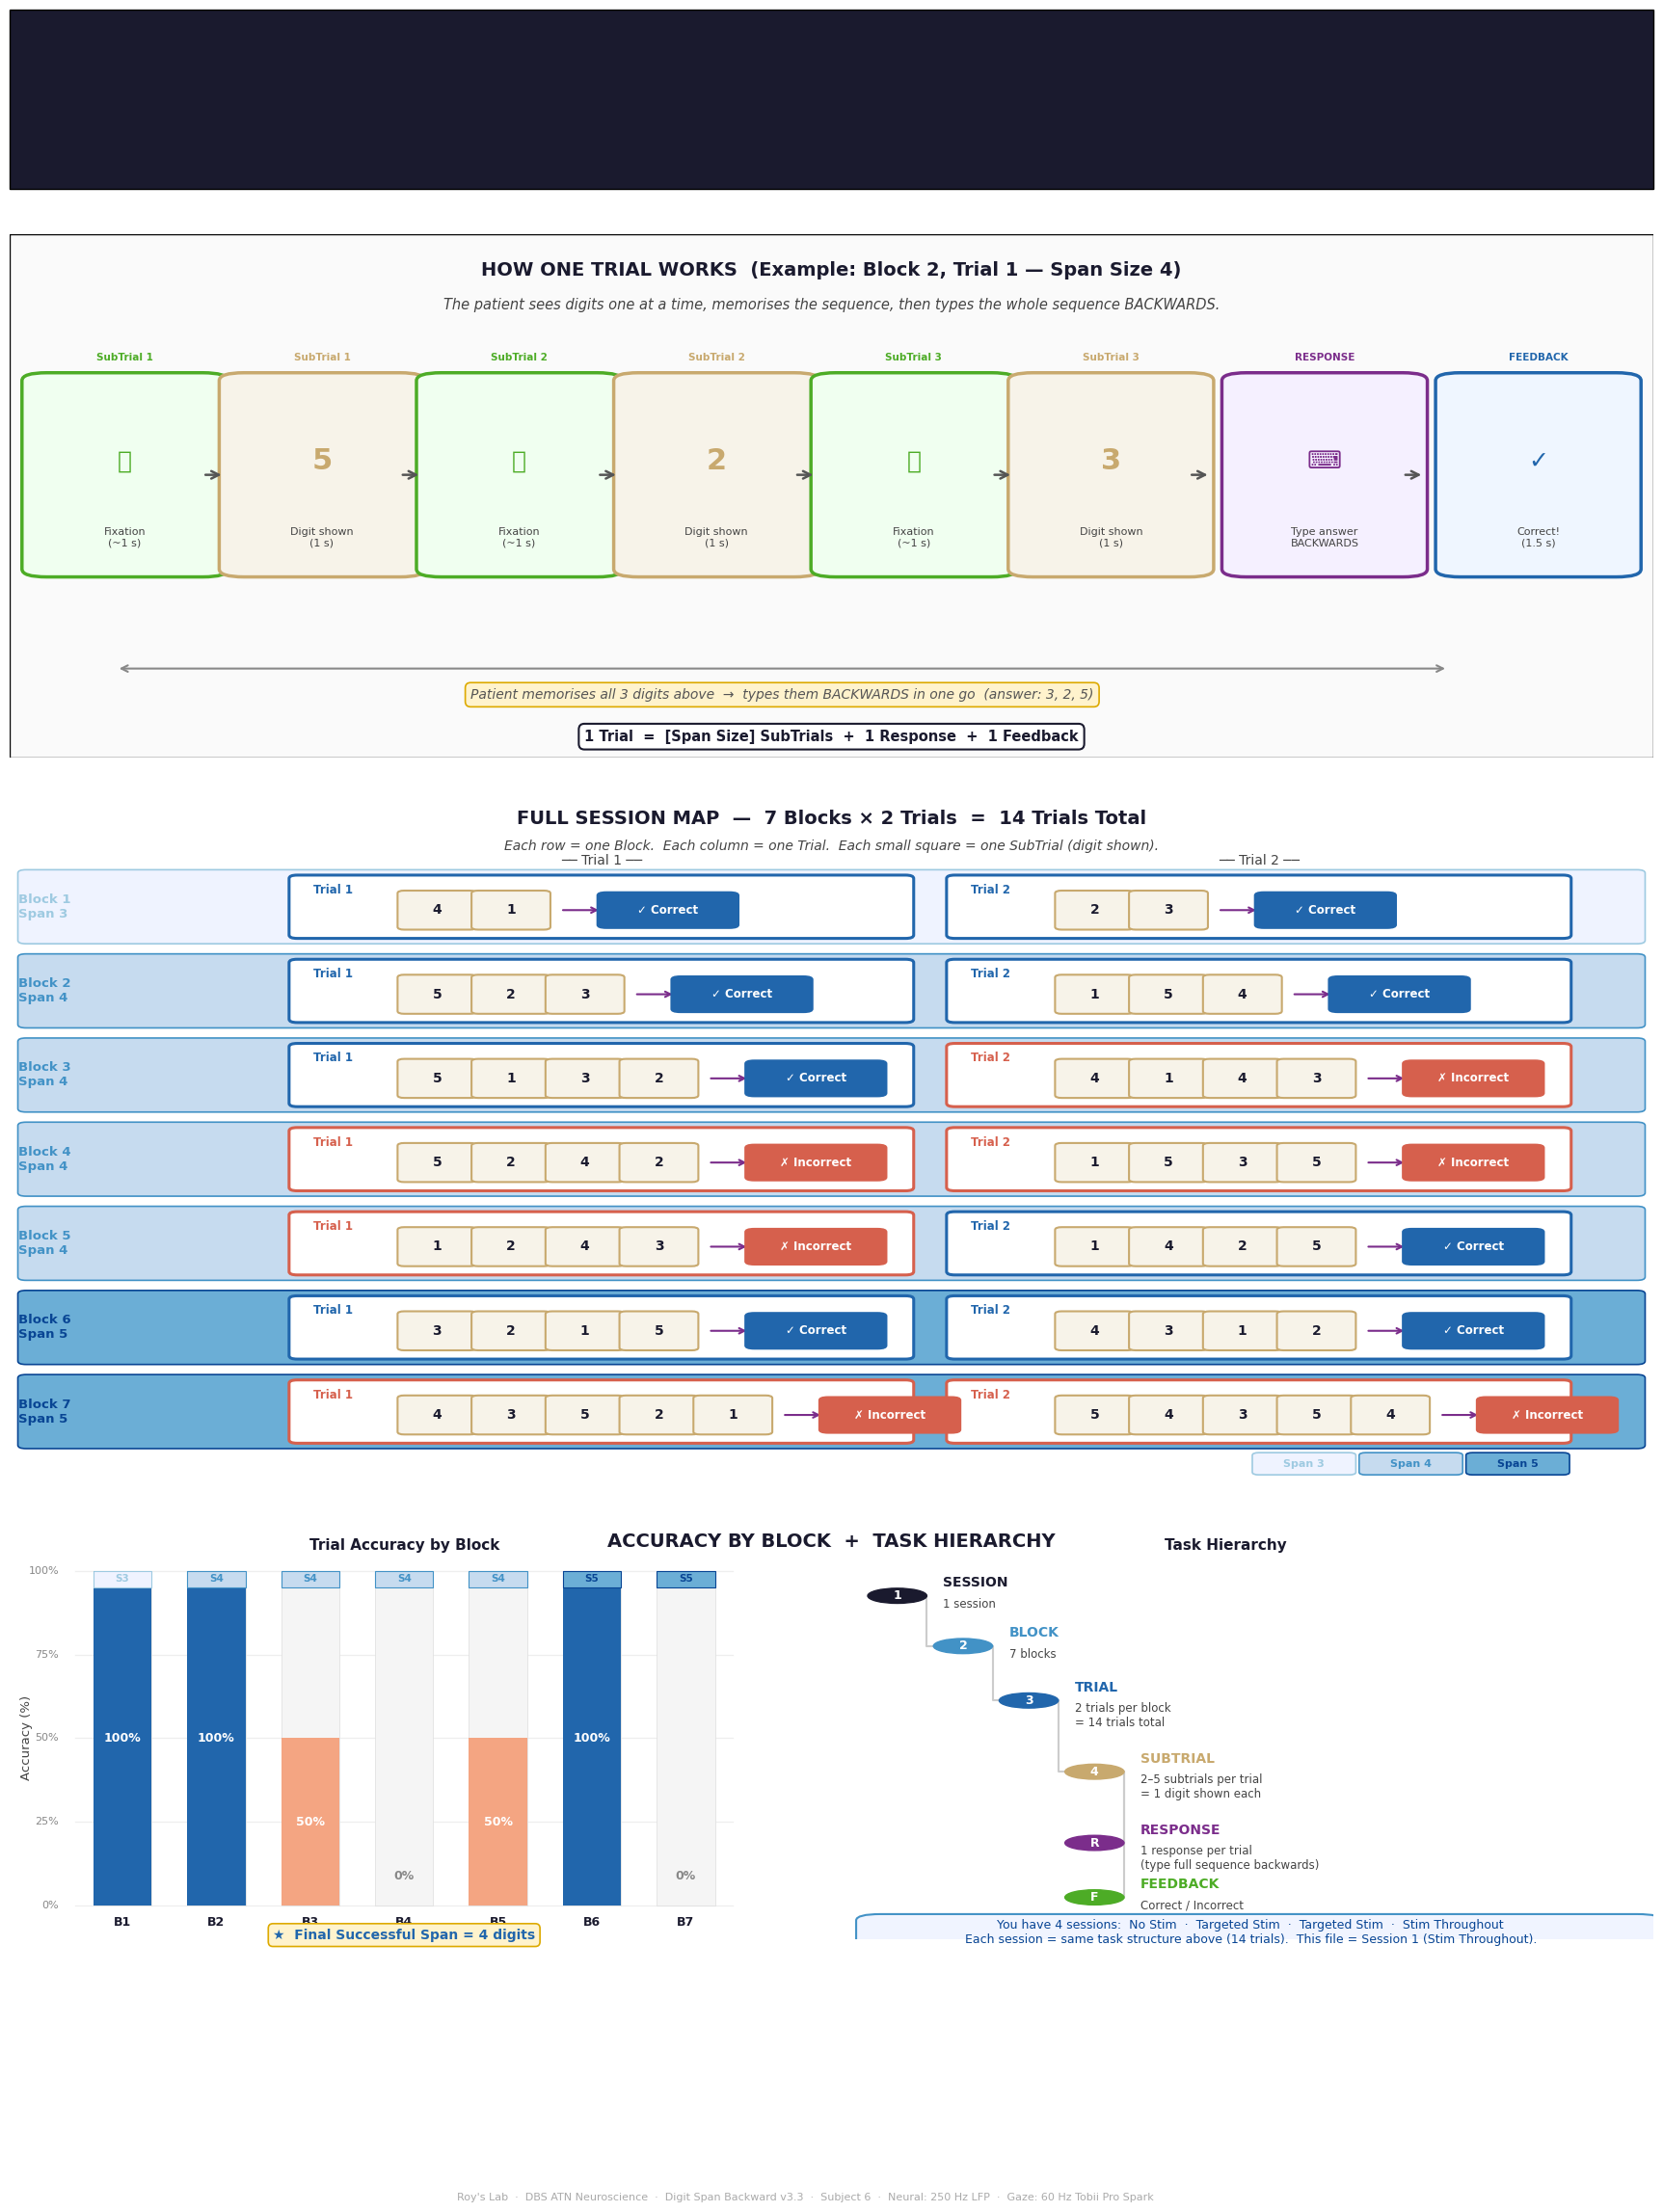

Plot shown and saved: task_structure_visual.png


In [1]:
# ==============================================================================
# TASK STRUCTURE VISUAL EXPLAINER
# Digit Span Backward — Subject 6, Session 1
# Roy's Lab — DBS Neuroscience Project
#
# Run this cell in your Jupyter notebook.
# Output is shown inline — nothing is just saved.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as pe
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# COLOUR PALETTE  — clean, publication-quality, white background
# ==============================================================================
C = {
    'correct'   : '#2166AC',   # strong blue   — correct trial
    'incorrect' : '#D6604D',   # warm red      — incorrect trial
    'digit_box' : '#F7F3E9',   # warm cream    — digit card background
    'digit_border':'#C8A96E',  # gold border   — digit card
    'fix'       : '#4DAC26',   # green         — fixation cross
    'response'  : '#7B2D8B',   # purple        — response phase
    'feedback_c': '#2166AC',   # blue          — correct feedback
    'feedback_i': '#D6604D',   # red           — incorrect feedback
    'span3'     : '#EFF3FF',   # lightest blue — span 3 bg
    'span4'     : '#C6DBEF',   # medium blue   — span 4 bg
    'span5'     : '#6BAED6',   # deeper blue   — span 5 bg
    'arrow'     : '#555555',
    'text_dark' : '#1A1A2E',
    'text_mid'  : '#444444',
    'text_light': '#888888',
    'bg'        : 'white',
    'grid'      : '#EEEEEE',
    'highlight' : '#FFF3CD',   # warm yellow highlight
}

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'font.family'      : 'DejaVu Sans',
    'text.color'       : C['text_dark'],
})

# ==============================================================================
# DATA — exact from scores file
# ==============================================================================
blocks = [
    # (block, span, trial1_digits, trial1_acc, trial2_digits, trial2_acc)
    (1, 3, [4,1],       1, [2,3],       1),
    (2, 4, [5,2,3],     1, [1,5,4],     1),
    (3, 4, [5,1,3,2],   1, [4,1,4,3],   0),
    (4, 4, [5,2,4,2],   0, [1,5,3,5],   0),
    (5, 4, [1,2,4,3],   0, [1,4,2,5],   1),
    (6, 5, [3,2,1,5],   1, [4,3,1,2],   1),
    (7, 5, [4,3,5,2,1], 0, [5,4,3,5,4], 0),
]

# ==============================================================================
# FIGURE LAYOUT
# ==============================================================================
fig = plt.figure(figsize=(22, 26), facecolor='white')
fig.patch.set_facecolor('white')

gs = GridSpec(4, 1, figure=fig,
              height_ratios=[1.2, 3.5, 4.5, 2.8],
              hspace=0.10)

ax_title   = fig.add_subplot(gs[0])   # big title + legend
ax_flow    = fig.add_subplot(gs[1])   # single trial flow diagram
ax_blocks  = fig.add_subplot(gs[2])   # all 7 blocks × 2 trials
ax_summary = fig.add_subplot(gs[3])   # accuracy summary + hierarchy tree

for ax in [ax_title, ax_flow, ax_blocks, ax_summary]:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

# ==============================================================================
# PANEL 0 — TITLE BANNER
# ==============================================================================
ax_title.set_facecolor(C['text_dark'])
fig.patches.extend([
    FancyBboxPatch((0, 0), 1, 1,
                   boxstyle="square,pad=0",
                   transform=ax_title.transAxes,
                   facecolor=C['text_dark'], zorder=0,
                   clip_on=False)
])

ax_title.text(0.5, 0.72,
    "DIGIT SPAN BACKWARD — Task Structure",
    ha='center', va='center', fontsize=26, fontweight='bold',
    color='white', transform=ax_title.transAxes,
    fontfamily='DejaVu Sans')

ax_title.text(0.5, 0.32,
    "Subject 6  ·  Session 1  ·  2026-03-05  ·  Roy's Lab DBS Neuroscience Project",
    ha='center', va='center', fontsize=13, color='#AAAAAA',
    transform=ax_title.transAxes)

# Legend chips in title bar
legend_items = [
    (0.18, '✓  Correct Trial',   C['correct']),
    (0.40, '✗  Incorrect Trial', C['incorrect']),
    (0.60, '➕  Fixation Cross',  C['fix']),
    (0.78, '⌨  Response Phase',  C['response']),
]
for xpos, lbl, col in legend_items:
    ax_title.add_patch(FancyBboxPatch(
        (xpos - 0.08, 0.02), 0.16, 0.18,
        boxstyle="round,pad=0.01", linewidth=0,
        facecolor=col, alpha=0.85,
        transform=ax_title.transAxes, zorder=5))
    ax_title.text(xpos, 0.11, lbl,
        ha='center', va='center', fontsize=10,
        color='white', fontweight='bold',
        transform=ax_title.transAxes, zorder=6)

# ==============================================================================
# PANEL 1 — HOW ONE TRIAL WORKS  (flow diagram)
# ==============================================================================
ax_flow.set_facecolor('#FAFAFA')
ax_flow.add_patch(FancyBboxPatch((0,0), 1, 1,
    boxstyle="square,pad=0", facecolor='#FAFAFA',
    transform=ax_flow.transAxes, zorder=0))

ax_flow.text(0.5, 0.93,
    "HOW ONE TRIAL WORKS  (Example: Block 2, Trial 1 — Span Size 4)",
    ha='center', va='center', fontsize=14, fontweight='bold',
    color=C['text_dark'], transform=ax_flow.transAxes)

ax_flow.text(0.5, 0.865,
    "The patient sees digits one at a time, memorises the sequence, then types the whole sequence BACKWARDS.",
    ha='center', va='center', fontsize=10.5, color=C['text_mid'],
    transform=ax_flow.transAxes, style='italic')

# ── Step boxes ────────────────────────────────────────────────────────────────
steps = [
    # (x_center, label_top, label_mid, label_bot, color, shape)
    (0.07,  'SubTrial 1', '➕',       'Fixation\n(~1 s)',       C['fix'],      'fix'),
    (0.19,  'SubTrial 1', '5',        'Digit shown\n(1 s)',     C['digit_border'], 'digit'),
    (0.31,  'SubTrial 2', '➕',       'Fixation\n(~1 s)',       C['fix'],      'fix'),
    (0.43,  'SubTrial 2', '2',        'Digit shown\n(1 s)',     C['digit_border'], 'digit'),
    (0.55,  'SubTrial 3', '➕',       'Fixation\n(~1 s)',       C['fix'],      'fix'),
    (0.67,  'SubTrial 3', '3',        'Digit shown\n(1 s)',     C['digit_border'], 'digit'),
    (0.80,  'RESPONSE',   '⌨',        'Type answer\nBACKWARDS', C['response'], 'resp'),
    (0.93,  'FEEDBACK',   '✓',        'Correct!\n(1.5 s)',      C['correct'],  'feed'),
]

box_y   = 0.38
box_h   = 0.32
box_w   = 0.095

for i, (xc, top_lbl, mid_lbl, bot_lbl, col, stype) in enumerate(steps):
    xl = xc - box_w / 2
    # background box
    bg_col = C['digit_box'] if stype == 'digit' else (
             '#F0FFF0' if stype == 'fix' else
             '#F5F0FF' if stype == 'resp' else
             '#EFF6FF')
    ax_flow.add_patch(FancyBboxPatch(
        (xl, box_y - 0.02), box_w, box_h + 0.04,
        boxstyle="round,pad=0.015", linewidth=2.5,
        edgecolor=col, facecolor=bg_col,
        transform=ax_flow.transAxes, zorder=3))

    # subtrial label at top
    ax_flow.text(xc, box_y + box_h + 0.055, top_lbl,
        ha='center', va='bottom', fontsize=7.5,
        color=col, fontweight='bold',
        transform=ax_flow.transAxes)

    # big centre symbol/digit
    fontsize_mid = 22 if stype == 'digit' else 18
    ax_flow.text(xc, box_y + box_h * 0.58, mid_lbl,
        ha='center', va='center', fontsize=fontsize_mid,
        color=col, fontweight='bold',
        transform=ax_flow.transAxes, zorder=4)

    # bottom label
    ax_flow.text(xc, box_y + 0.04, bot_lbl,
        ha='center', va='center', fontsize=8,
        color=C['text_mid'],
        transform=ax_flow.transAxes)

    # arrow to next step
    if i < len(steps) - 1:
        ax_flow.annotate('',
            xy=(xc + box_w / 2 + 0.013, box_y + box_h / 2),
            xytext=(xc + box_w / 2, box_y + box_h / 2),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color=C['arrow'],
                           lw=1.8, mutation_scale=14),
            zorder=5)

# "ONE response for the whole sequence" bracket
ax_flow.annotate('', xy=(0.875, 0.17), xytext=(0.065, 0.17),
    xycoords='axes fraction', textcoords='axes fraction',
    arrowprops=dict(arrowstyle='<->', color='#888888',
                   lw=1.5, mutation_scale=12))
ax_flow.text(0.47, 0.12,
    "Patient memorises all 3 digits above  →  types them BACKWARDS in one go  (answer: 3, 2, 5)",
    ha='center', va='center', fontsize=10, color='#555555',
    transform=ax_flow.transAxes, style='italic',
    bbox=dict(boxstyle='round,pad=0.4', facecolor=C['highlight'],
              edgecolor='#DDAA00', linewidth=1.2))

# Hierarchy note
ax_flow.text(0.5, 0.04,
    "1 Trial  =  [Span Size] SubTrials  +  1 Response  +  1 Feedback",
    ha='center', va='center', fontsize=10.5, fontweight='bold',
    color=C['text_dark'], transform=ax_flow.transAxes,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor=C['text_dark'], linewidth=1.5))

# ==============================================================================
# PANEL 2 — ALL BLOCKS × TRIALS  (the full session map)
# ==============================================================================
ax_blocks.set_facecolor('white')

ax_blocks.text(0.5, 0.975,
    "FULL SESSION MAP  —  7 Blocks × 2 Trials  =  14 Trials Total",
    ha='center', va='center', fontsize=14, fontweight='bold',
    color=C['text_dark'], transform=ax_blocks.transAxes)

ax_blocks.text(0.5, 0.935,
    "Each row = one Block.  Each column = one Trial.  Each small square = one SubTrial (digit shown).",
    ha='center', va='center', fontsize=10, color=C['text_mid'],
    transform=ax_blocks.transAxes, style='italic')

span_colors = {3: '#EFF3FF', 4: '#C6DBEF', 5: '#6BAED6'}
span_border = {3: '#9ECAE1', 4: '#4292C6', 5: '#084594'}

block_top    = 0.895
block_height = 0.10
block_gap    = 0.025
trial_left   = [0.18, 0.58]   # x start of trial 1 and trial 2

for bi, (blk, span, t1d, t1a, t2d, t2a) in enumerate(blocks):
    y_top = block_top - bi * (block_height + block_gap)
    y_bot = y_top - block_height
    y_mid = (y_top + y_bot) / 2

    # Block background stripe
    ax_blocks.add_patch(FancyBboxPatch(
        (0.01, y_bot), 0.98, block_height,
        boxstyle="round,pad=0.005",
        facecolor=span_colors[span], edgecolor=span_border[span],
        linewidth=1.2, transform=ax_blocks.transAxes, zorder=1))

    # Block label left
    ax_blocks.text(0.005, y_mid,
        f"Block {blk}\nSpan {span}",
        ha='left', va='center', fontsize=9.5, fontweight='bold',
        color=span_border[span], transform=ax_blocks.transAxes)

    # Draw both trials
    for ti, (t_digits, t_acc) in enumerate([(t1d, t1a), (t2d, t2a)]):
        tx = trial_left[ti]
        acc_col   = C['correct'] if t_acc == 1 else C['incorrect']
        acc_label = '✓ Correct' if t_acc == 1 else '✗ Incorrect'

        # Trial container
        trial_w = 0.37
        ax_blocks.add_patch(FancyBboxPatch(
            (tx - 0.005, y_bot + 0.008), trial_w, block_height - 0.016,
            boxstyle="round,pad=0.005",
            facecolor='white', edgecolor=acc_col,
            linewidth=2.2, transform=ax_blocks.transAxes, zorder=2))

        # Trial label
        ax_blocks.text(tx + 0.005, y_mid + block_height * 0.25,
            f"Trial {ti+1}",
            ha='left', va='center', fontsize=8.5, fontweight='bold',
            color=acc_col, transform=ax_blocks.transAxes)

        # Digit squares
        sq_w   = 0.040
        sq_h   = block_height * 0.50
        sq_gap = 0.005
        sq_x0  = tx + 0.06
        sq_y   = y_mid - sq_h / 2 - 0.005

        for di, digit in enumerate(t_digits):
            sx = sq_x0 + di * (sq_w + sq_gap)
            ax_blocks.add_patch(FancyBboxPatch(
                (sx, sq_y), sq_w, sq_h,
                boxstyle="round,pad=0.004",
                facecolor=C['digit_box'], edgecolor=C['digit_border'],
                linewidth=1.5, transform=ax_blocks.transAxes, zorder=3))
            ax_blocks.text(sx + sq_w / 2, sq_y + sq_h / 2,
                str(digit),
                ha='center', va='center', fontsize=10, fontweight='bold',
                color=C['text_dark'], transform=ax_blocks.transAxes, zorder=4)

        # Arrow after digits → response
        resp_x = sq_x0 + len(t_digits) * (sq_w + sq_gap) + 0.005
        ax_blocks.annotate('',
            xy=(resp_x + 0.025, sq_y + sq_h / 2),
            xytext=(resp_x, sq_y + sq_h / 2),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color=C['response'],
                           lw=1.5, mutation_scale=10), zorder=4)

        # Outcome chip
        chip_x = resp_x + 0.028
        chip_w = 0.075
        ax_blocks.add_patch(FancyBboxPatch(
            (chip_x, sq_y + 0.003), chip_w, sq_h - 0.006,
            boxstyle="round,pad=0.006",
            facecolor=acc_col, edgecolor='none',
            transform=ax_blocks.transAxes, zorder=4))
        ax_blocks.text(chip_x + chip_w / 2, sq_y + sq_h / 2,
            acc_label,
            ha='center', va='center', fontsize=8.5,
            color='white', fontweight='bold',
            transform=ax_blocks.transAxes, zorder=5)

# Column headers
for ti, tx in enumerate(trial_left):
    ax_blocks.text(tx + 0.18, block_top + 0.008,
        f"── Trial {ti+1} ──",
        ha='center', va='bottom', fontsize=10,
        color=C['text_mid'], transform=ax_blocks.transAxes)

# Span size legend
for span, col, bc in [(3, '#EFF3FF', '#9ECAE1'),
                       (4, '#C6DBEF', '#4292C6'),
                       (5, '#6BAED6', '#084594')]:
    lx = 0.01 + (span - 3) * 0.085
    ax_blocks.add_patch(FancyBboxPatch(
        (0.76 + (span-3)*0.065, 0.005), 0.055, 0.025,
        boxstyle="round,pad=0.004",
        facecolor=col, edgecolor=bc, linewidth=1.2,
        transform=ax_blocks.transAxes, zorder=3))
    ax_blocks.text(0.76 + (span-3)*0.065 + 0.0275, 0.0175,
        f"Span {span}",
        ha='center', va='center', fontsize=8, fontweight='bold',
        color=bc, transform=ax_blocks.transAxes)

# ==============================================================================
# PANEL 3 — ACCURACY SUMMARY + HIERARCHY TREE
# ==============================================================================
ax_summary.set_facecolor('white')

ax_summary.text(0.5, 0.97,
    "ACCURACY BY BLOCK  +  TASK HIERARCHY",
    ha='center', va='top', fontsize=14, fontweight='bold',
    color=C['text_dark'], transform=ax_summary.transAxes)

# ── Left: accuracy bar chart (hand-drawn in axes) ─────────────────────────────
bar_data = [
    (1, 3, 2, 2),   # block, span, correct_trials, total_trials
    (2, 4, 2, 2),
    (3, 4, 1, 2),
    (4, 4, 0, 2),
    (5, 4, 1, 2),
    (6, 5, 2, 2),
    (7, 5, 0, 2),
]

chart_l, chart_r = 0.04, 0.44
chart_b, chart_t = 0.08, 0.88
chart_w = chart_r - chart_l
chart_h = chart_t - chart_b

n_blocks  = len(bar_data)
bar_width = chart_w / n_blocks * 0.62
gap       = chart_w / n_blocks * 0.38

# Grid lines
for pct in [0, 25, 50, 75, 100]:
    gy = chart_b + chart_h * pct / 100
    ax_summary.plot([chart_l, chart_r], [gy, gy],
        color=C['grid'], lw=0.9, transform=ax_summary.transAxes, zorder=1)
    ax_summary.text(chart_l - 0.01, gy, f"{pct}%",
        ha='right', va='center', fontsize=8, color=C['text_light'],
        transform=ax_summary.transAxes)

# Bars
for i, (blk, span, corr, total) in enumerate(bar_data):
    pct    = corr / total
    bx     = chart_l + i * (bar_width + gap) + gap / 2
    bh     = chart_h * pct
    col    = C['correct'] if pct == 1.0 else (
             C['incorrect'] if pct == 0.0 else '#F4A582')
    bc     = span_border[span]

    # Full height background (shows max possible)
    ax_summary.add_patch(FancyBboxPatch(
        (bx, chart_b), bar_width, chart_h,
        boxstyle="square,pad=0",
        facecolor='#F5F5F5', edgecolor='#DDDDDD', linewidth=0.5,
        transform=ax_summary.transAxes, zorder=2))

    # Actual accuracy bar
    if bh > 0:
        ax_summary.add_patch(FancyBboxPatch(
            (bx, chart_b), bar_width, bh,
            boxstyle="square,pad=0",
            facecolor=col, edgecolor='none',
            transform=ax_summary.transAxes, zorder=3))

    # Span size stripe at top
    ax_summary.add_patch(FancyBboxPatch(
        (bx, chart_t - 0.04), bar_width, 0.04,
        boxstyle="square,pad=0",
        facecolor=span_colors[span], edgecolor=bc, linewidth=0.8,
        transform=ax_summary.transAxes, zorder=4))
    ax_summary.text(bx + bar_width / 2, chart_t - 0.02, f"S{span}",
        ha='center', va='center', fontsize=7.5, fontweight='bold',
        color=bc, transform=ax_summary.transAxes, zorder=5)

    # Percentage label inside bar
    label_y = chart_b + bh / 2 if bh > 0.06 else chart_b + 0.07
    ax_summary.text(bx + bar_width / 2, label_y,
        f"{int(pct*100)}%",
        ha='center', va='center', fontsize=9, fontweight='bold',
        color='white' if pct > 0 else C['text_light'],
        transform=ax_summary.transAxes, zorder=5)

    # Block label below
    ax_summary.text(bx + bar_width / 2, chart_b - 0.025,
        f"B{blk}",
        ha='center', va='top', fontsize=9, fontweight='bold',
        color=C['text_dark'], transform=ax_summary.transAxes)

# Chart axes labels
ax_summary.text((chart_l + chart_r) / 2, 0.02,
    "Block Number  (B = Block, S = Span Size)",
    ha='center', va='center', fontsize=9.5, color=C['text_mid'],
    transform=ax_summary.transAxes)
ax_summary.text(0.01, (chart_b + chart_t) / 2,
    "Accuracy (%)",
    ha='center', va='center', fontsize=9.5, color=C['text_mid'],
    transform=ax_summary.transAxes, rotation=90)
ax_summary.text((chart_l + chart_r) / 2, 0.94,
    "Trial Accuracy by Block",
    ha='center', va='center', fontsize=11, fontweight='bold',
    color=C['text_dark'], transform=ax_summary.transAxes)

# Final span note
ax_summary.text((chart_l + chart_r) / 2, chart_b - 0.07,
    "★  Final Successful Span = 4 digits",
    ha='center', va='center', fontsize=10, fontweight='bold',
    color=C['correct'], transform=ax_summary.transAxes,
    bbox=dict(boxstyle='round,pad=0.35', facecolor=C['highlight'],
              edgecolor='#DDAA00', linewidth=1.2))

# ── Right: hierarchy tree ─────────────────────────────────────────────────────
tx0 = 0.52

ax_summary.text(tx0 + 0.22, 0.94,
    "Task Hierarchy",
    ha='center', va='center', fontsize=11, fontweight='bold',
    color=C['text_dark'], transform=ax_summary.transAxes)

tree = [
    # (level, y, label, sublabel, color)
    (0, 0.82, "SESSION",    "1 session",         '#1A1A2E'),
    (1, 0.70, "BLOCK",      "7 blocks",           span_border[4]),
    (2, 0.57, "TRIAL",      "2 trials per block\n= 14 trials total", C['correct']),
    (3, 0.40, "SUBTRIAL",   "2–5 subtrials per trial\n= 1 digit shown each", C['digit_border']),
    (4, 0.23, "RESPONSE",   "1 response per trial\n(type full sequence backwards)", C['response']),
    (4, 0.10, "FEEDBACK",   "Correct / Incorrect\nshown after response", C['fix']),
]

node_x = [tx0 + 0.02, tx0 + 0.06, tx0 + 0.10, tx0 + 0.14, tx0 + 0.14, tx0 + 0.14]

for i, (level, y, lbl, sublbl, col) in enumerate(tree):
    nx = node_x[level]

    # Connecting line from parent
    if i > 0:
        parent_level = tree[i-1][0] if tree[i-1][0] < level else tree[i-2][0]
        parent_y     = tree[i-1][1] if tree[i-1][0] < level else tree[i-2][1]
        px = node_x[parent_level]
        ax_summary.plot([px + 0.018, px + 0.018, nx],
                        [parent_y, y, y],
                        color='#CCCCCC', lw=1.5, solid_capstyle='round',
                        transform=ax_summary.transAxes, zorder=2)

    # Node circle
    circ = plt.Circle((nx, y), 0.018, color=col, zorder=4,
                       transform=ax_summary.transAxes)
    ax_summary.add_patch(circ)
    ax_summary.text(nx, y, str(i+1) if i < 4 else ('R' if i==4 else 'F'),
        ha='center', va='center', fontsize=9, fontweight='bold',
        color='white', transform=ax_summary.transAxes, zorder=5)

    # Label and sublabel
    ax_summary.text(nx + 0.028, y + 0.015, lbl,
        ha='left', va='bottom', fontsize=10, fontweight='bold',
        color=col, transform=ax_summary.transAxes)
    ax_summary.text(nx + 0.028, y - 0.005, sublbl,
        ha='left', va='top', fontsize=8.5, color=C['text_mid'],
        transform=ax_summary.transAxes)

# 4 conditions note
ax_summary.add_patch(FancyBboxPatch(
    (tx0 + 0.01, -0.02), 0.46, 0.065,
    boxstyle="round,pad=0.015",
    facecolor='#F0F4FF', edgecolor='#4292C6', linewidth=1.5,
    transform=ax_summary.transAxes, zorder=3))
ax_summary.text(tx0 + 0.235, 0.015,
    "You have 4 sessions:  No Stim  ·  Targeted Stim  ·  Targeted Stim  ·  Stim Throughout\n"
    "Each session = same task structure above (14 trials).  This file = Session 1 (Stim Throughout).",
    ha='center', va='center', fontsize=9, color='#084594',
    transform=ax_summary.transAxes)

# ==============================================================================
# FOOTER
# ==============================================================================
fig.text(0.5, 0.005,
    "Roy's Lab  ·  DBS ATN Neuroscience  ·  Digit Span Backward v3.3  ·  Subject 6  ·  "
    "Neural: 250 Hz LFP  ·  Gaze: 60 Hz Tobii Pro Spark",
    ha='center', va='bottom', fontsize=8, color='#AAAAAA')

plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.savefig('task_structure_visual.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Plot shown and saved: task_structure_visual.png")